In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# Generate realistic house data: surface (m²) vs price (thousands €)
# Typical relationship: price = 2.5k€ per m² + 50k€ base price
np.random.seed(42)
x_data = np.random.uniform(30, 200, 50)  # House surface: 30-200 m²
true_W, true_b = 2.5, 50  # 2.5k€ per m², 50k€ base
y_data = true_W * x_data + true_b + np.random.randn(len(x_data)) * 30  # Add noise

def plot_line(W=1.0, b=0.0):
    plt.figure(figsize=(10, 6))
    
    # Plot scatter points
    plt.scatter(x_data, y_data, c='blue', alpha=0.6, label='Houses')
    
    # Plot adjustable line
    x_line = np.linspace(20, 220, 100)
    y_line = W * x_line + b
    plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'price = {W:.1f} x surface + {b:.0f}')
    
    plt.xlim(20, 220)
    plt.ylim(0, 700)
    plt.xlabel('House Surface (m²)')
    plt.ylabel('Price (thousands €)')
    plt.title('Interactive Linear Regression: Price = W x Surface + b')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

interact(
    plot_line,
    W=FloatSlider(min=0, max=5, step=0.1, value=1.0, description='W (€k/m²)'),
    b=FloatSlider(min=-50, max=200, step=5, value=0.0, description='b (base €k)')
)

interactive(children=(FloatSlider(value=1.0, description='W (€k/m²)', max=5.0), FloatSlider(value=0.0, descrip…

<function __main__.plot_line(W=1.0, b=0.0)>

In [2]:
def calculate_mse(W, b):
    """Calculate Mean Squared Error"""
    y_pred = W * x_data + b
    return np.mean((y_data - y_pred) ** 2)

# Precompute MSE values for 3D scatter plot (sparser grid for scatter)
W_range = np.linspace(0, 5, 25)
b_range = np.linspace(-50, 200, 25)
W_pts, b_pts, mse_pts = [], [], []

for w in W_range:
    for b in b_range:
        W_pts.append(w)
        b_pts.append(b)
        mse_pts.append(calculate_mse(w, b))

W_pts = np.array(W_pts)
b_pts = np.array(b_pts)
mse_pts = np.array(mse_pts)

from ipywidgets import IntSlider

mse_history = []

def plot_with_mse(W=1.0, b=0.0, azimuth=45, elevation=25):
    mse = calculate_mse(W, b)
    mse_history.append({'W': W, 'b': b, 'mse': mse})
    
    fig = plt.figure(figsize=(14, 5))
    
    # Left plot: scatter data + line (2D)
    ax1 = fig.add_subplot(1, 2, 1)
    
    # Calculate predicted values for each data point
    y_pred = W * x_data + b
    
    # Draw dotted lines from actual points to predicted points (residuals)
    for i in range(len(x_data)):
        ax1.plot([x_data[i], x_data[i]], [y_data[i], y_pred[i]], 
                 'gray', linestyle='--', linewidth=1, alpha=0.5)
    
    ax1.scatter(x_data, y_data, c='blue', alpha=0.6, label='Houses', zorder=5)
    x_line = np.linspace(20, 220, 100)
    y_line = W * x_line + b
    ax1.plot(x_line, y_line, 'r-', linewidth=2, label=f'price = {W:.1f} × surface + {b:.0f}')
    ax1.set_xlim(20, 220)
    ax1.set_ylim(0, 700)
    ax1.set_xlabel('House Surface (m²)')
    ax1.set_ylabel('Price (thousands €)')
    ax1.set_title(f'Linear Regression')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Right plot: 3D scatter of MSE error surface (bowl shape)
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    scatter = ax2.scatter(W_pts, b_pts, mse_pts, c=mse_pts, cmap='viridis', alpha=0.6, s=20)
    
    # Plot history trail
    if len(mse_history) > 1:
        hist_W = [h['W'] for h in mse_history[:-1]]
        hist_b = [h['b'] for h in mse_history[:-1]]
        hist_mse = [h['mse'] for h in mse_history[:-1]]
        ax2.scatter(hist_W, hist_b, hist_mse, c='white', s=50, edgecolors='black', linewidths=0.5)
    
    # Mark current position
    ax2.scatter([W], [b], [mse], c='red', s=200, marker='X', edgecolors='white', linewidths=2)
    
    ax2.set_xlabel('W (slope)')
    ax2.set_ylabel('b (intercept)')
    ax2.set_zlabel('MSE')
    ax2.set_title(f'Error Surface (MSE: {mse:.1f})')
    ax2.view_init(elev=elevation, azim=azimuth)
    
    plt.tight_layout()
    plt.show()

mse_history.clear() if mse_history else None

interact(
    plot_with_mse,
    W=FloatSlider(min=0, max=5, step=0.1, value=1.0, description='W (€k/m²)'),
    b=FloatSlider(min=-50, max=200, step=5, value=0.0, description='b (base €k)'),
    azimuth=IntSlider(min=0, max=360, step=5, value=45, description='Rotate (°)'),
    elevation=IntSlider(min=0, max=90, step=5, value=25, description='Tilt (°)')
)

interactive(children=(FloatSlider(value=1.0, description='W (€k/m²)', max=5.0), FloatSlider(value=0.0, descrip…

<function __main__.plot_with_mse(W=1.0, b=0.0, azimuth=45, elevation=25)>

In [3]:
from sklearn.linear_model import SGDRegressor

MAX_EPOCHS = 15
SEED = 1222

def calculate_mse(W, b):
    """Calculate Mean Squared Error"""
    y_pred = W * x_data + b
    return np.mean((y_data - y_pred) ** 2)

# Reshape x_data for sklearn (needs 2D array)
X_train = x_data.reshape(-1, 1)

from sklearn.preprocessing import StandardScaler

# Normalize features for stable training
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_train)
y_scaled = scaler_y.fit_transform(y_data.reshape(-1, 1)).ravel()

# Random initial W and b within the visualization range
np.random.seed(SEED)  # Change this SEED for different starting points
W_init = np.random.uniform(0, 5)      # W range: 0 to 5
b_init = np.random.uniform(-50, 200)  # b range: -50 to 200

# Convert initial values to normalized scale
W_init_scaled = W_init * scaler_X.scale_[0] / scaler_y.scale_[0]
b_init_scaled = (b_init + W_init * scaler_X.mean_[0] - scaler_y.mean_[0]) / scaler_y.scale_[0]

model = SGDRegressor(
    loss="squared_error",
    learning_rate='constant',
    eta0=0.01,
    max_iter=1,
    tol=None,
    warm_start=True,
)

# Initialize model and set custom starting weights
model.partial_fit(X_scaled, y_scaled)
model.coef_ = np.array([W_init_scaled])
model.intercept_ = np.array([b_init_scaled])

# Store history of W, b, mse at each epoch (including initial state)
sgd_history = [{'W': W_init, 'b': b_init, 'mse': calculate_mse(W_init, b_init)}]

for epoch in range(MAX_EPOCHS):
    model.partial_fit(X_scaled, y_scaled)
    
    # Convert normalized coefficients back to original scale for visualization
    W_scaled, b_scaled = model.coef_[0], model.intercept_[0]
    W = W_scaled * scaler_y.scale_[0] / scaler_X.scale_[0]
    b = b_scaled * scaler_y.scale_[0] + scaler_y.mean_[0] - W * scaler_X.mean_[0]
    
    sgd_history.append({'W': W, 'b': b, 'mse': calculate_mse(W, b)})

print(f"Training complete! Final W = {sgd_history[-1]['W']:.4f}, b = {sgd_history[-1]['b']:.2f}, MSE = {sgd_history[-1]['mse']:.2f}")

# Precompute MSE values for 3D scatter plot (sparser grid for scatter)
W_range = np.linspace(0, 5, 25)
b_range = np.linspace(-50, 200, 25)
W_pts, b_pts, mse_pts = [], [], []

for w in W_range:
    for b in b_range:
        W_pts.append(w)
        b_pts.append(b)
        mse_pts.append(calculate_mse(w, b))

W_pts = np.array(W_pts)
b_pts = np.array(b_pts)
mse_pts = np.array(mse_pts)

from ipywidgets import IntSlider

def plot_with_mse(epoch=0):
    # Get W, b, mse from the training history at this epoch
    current = sgd_history[epoch]
    W, b, mse = current['W'], current['b'], current['mse']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left plot: scatter data + line (2D)
    y_pred = W * x_data + b
    
    # Draw dotted lines from actual points to predicted points (residuals)
    for i in range(len(x_data)):
        ax1.plot([x_data[i], x_data[i]], [y_data[i], y_pred[i]], 
                 'gray', linestyle='--', linewidth=1, alpha=0.5)
    
    ax1.scatter(x_data, y_data, c='blue', alpha=0.6, label='Houses', zorder=5)
    x_line = np.linspace(20, 220, 100)
    y_line = W * x_line + b
    ax1.plot(x_line, y_line, 'r-', linewidth=2, label=f'price = {W:.2f} × surface + {b:.1f}')
    ax1.set_xlim(20, 220)
    ax1.set_ylim(0, 700)
    ax1.set_xlabel('House Surface (m²)')
    ax1.set_ylabel('Price (thousands €)')
    ax1.set_title(f'Epoch {epoch}: MSE = {mse:.1f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Right plot: Loss function (MSE over epochs) - only up to current epoch
    epochs_list = list(range(epoch + 1))
    mse_list = [sgd_history[e]['mse'] for e in range(epoch + 1)]
    
    ax2.plot(epochs_list, mse_list, 'b-', linewidth=2, marker='o', markersize=6)
    ax2.scatter([epoch], [mse], c='red', s=150, zorder=5, label=f'Current: {mse:.1f}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('MSE (Mean Squared Error)')
    ax2.set_title('Loss Function')
    ax2.set_xlim(-0.5, len(sgd_history) - 0.5)
    ax2.set_ylim(0, sgd_history[0]['mse'] * 1.1)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

interact(
    plot_with_mse,
    epoch=IntSlider(min=0, max=len(sgd_history)-1, step=1, value=0, description='Epoch')
)

Training complete! Final W = 2.4551, b = 54.72, MSE = 740.84


interactive(children=(IntSlider(value=0, description='Epoch', max=15), Output()), _dom_classes=('widget-intera…

<function __main__.plot_with_mse(epoch=0)>

In [4]:
# Comparing 1 Input vs Multiple Inputs

from sklearn.metrics import mean_squared_error

# Generate data with 2 features
np.random.seed(42)
n_samples = 50

# Feature 1: House surface (m²)
surface = np.random.uniform(30, 200, n_samples)

# Feature 2: Number of rooms (correlated with surface, but adds info)
rooms = (surface / 30 + np.random.randn(n_samples) * 1.5).clip(1, 8)

# True relationship: price = 2.0*surface + 15*rooms + 20 + noise
# (rooms has independent contribution to price beyond just surface)
true_w1, true_w2, true_bias = 2.0, 15.0, 20.0
price = true_w1 * surface + true_w2 * rooms + true_bias + np.random.randn(n_samples) * 25

# Prepare datasets
X_1input = surface.reshape(-1, 1)
X_2inputs = np.column_stack([surface, rooms])

# Normalize
scaler_1 = StandardScaler()
scaler_2 = StandardScaler()
scaler_y = StandardScaler()

X_1_scaled = scaler_1.fit_transform(X_1input)
X_2_scaled = scaler_2.fit_transform(X_2inputs)
y_scaled = scaler_y.fit_transform(price.reshape(-1, 1)).ravel()

# Train both models
MAX_EPOCHS = 15

# Model 1: Single input (surface only)
model_1 = SGDRegressor(learning_rate='constant', eta0=0.05, max_iter=1, tol=None, warm_start=True, random_state=42)
history_1 = []
for epoch in range(MAX_EPOCHS):
    model_1.partial_fit(X_1_scaled, y_scaled)
    y_pred = scaler_y.inverse_transform(model_1.predict(X_1_scaled).reshape(-1, 1)).ravel()
    history_1.append({'epoch': epoch, 'mse': mean_squared_error(price, y_pred)})

# Model 2: Two inputs (surface + rooms)
model_2 = SGDRegressor(learning_rate='constant', eta0=0.05, max_iter=1, tol=None, warm_start=True, random_state=42)
history_2 = []
for epoch in range(MAX_EPOCHS):
    model_2.partial_fit(X_2_scaled, y_scaled)
    y_pred = scaler_y.inverse_transform(model_2.predict(X_2_scaled).reshape(-1, 1)).ravel()
    history_2.append({'epoch': epoch, 'mse': mean_squared_error(price, y_pred)})

print("=== Model Comparison ===")
print(f"1 Input (surface only):     Final MSE = {history_1[-1]['mse']:.2f}")
print(f"2 Inputs (surface + rooms): Final MSE = {history_2[-1]['mse']:.2f}")
print(f"Improvement: {(1 - history_2[-1]['mse']/history_1[-1]['mse'])*100:.1f}% lower error")

def plot_comparison(epoch=0, azimuth=45, elevation=25):
    fig = plt.figure(figsize=(14, 10))
    
    # Retrain up to this epoch for accurate predictions
    m2 = SGDRegressor(learning_rate='constant', eta0=0.05, max_iter=1, tol=None, warm_start=True, random_state=42)
    for e in range(epoch + 1):
        m2.partial_fit(X_2_scaled, y_scaled)
    
    pred_2 = scaler_y.inverse_transform(m2.predict(X_2_scaled).reshape(-1, 1)).ravel()
    mse_2 = mean_squared_error(price, pred_2)
    
    # Get coefficients in original scale
    w_scaled = m2.coef_
    b_scaled = m2.intercept_[0]
    # Convert back to original scale
    w1 = w_scaled[0] * scaler_y.scale_[0] / scaler_2.scale_[0]
    w2 = w_scaled[1] * scaler_y.scale_[0] / scaler_2.scale_[1]
    b = b_scaled * scaler_y.scale_[0] + scaler_y.mean_[0] - w1 * scaler_2.mean_[0] - w2 * scaler_2.mean_[1]
    
    # Top left: Price vs Surface (2D) with regression line
    ax1 = fig.add_subplot(2, 2, 1)
    ax1.scatter(surface, price, c='blue', alpha=0.6, label='Actual')
    # Regression line: holding rooms at mean value
    surf_line = np.linspace(surface.min(), surface.max(), 100)
    price_line_surf = w1 * surf_line + w2 * np.mean(rooms) + b
    ax1.plot(surf_line, price_line_surf, 'r-', linewidth=2, label=f'w₁={w1:.2f} (rooms=mean)')
    ax1.set_xlabel('Surface (m²)')
    ax1.set_ylabel('Price (k€)')
    ax1.set_title(f'Price vs Surface')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Top right: Price vs Rooms (2D) with regression line
    ax2 = fig.add_subplot(2, 2, 2)
    ax2.scatter(rooms, price, c='blue', alpha=0.6, label='Actual')
    # Regression line: holding surface at mean value
    rooms_line = np.linspace(rooms.min(), rooms.max(), 100)
    price_line_rooms = w1 * np.mean(surface) + w2 * rooms_line + b
    ax2.plot(rooms_line, price_line_rooms, 'r-', linewidth=2, label=f'w₂={w2:.2f} (surface=mean)')
    ax2.set_xlabel('Rooms')
    ax2.set_ylabel('Price (k€)')
    ax2.set_title(f'Price vs Rooms')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Bottom left: 3D plot with regression plane
    ax3 = fig.add_subplot(2, 2, 3, projection='3d')
    ax3.scatter(surface, rooms, price, c='blue', alpha=0.7, s=40, label='Actual data')
    
    # Create regression plane
    surf_range = np.linspace(surface.min(), surface.max(), 20)
    room_range = np.linspace(rooms.min(), rooms.max(), 20)
    surf_grid, room_grid = np.meshgrid(surf_range, room_range)
    price_plane = w1 * surf_grid + w2 * room_grid + b
    
    ax3.plot_surface(surf_grid, room_grid, price_plane, alpha=0.3, color='red', label='Regression plane')
    ax3.set_xlabel('Surface (m²)')
    ax3.set_ylabel('Rooms')
    ax3.set_zlabel('Price (k€)')
    ax3.set_title(f'3D: price = {w1:.2f}×surface + {w2:.2f}×rooms + {b:.1f}')
    ax3.view_init(elev=elevation, azim=azimuth)
    
    # Bottom right: Loss over epochs
    ax4 = fig.add_subplot(2, 2, 4)
    epochs_list = [h['epoch'] for h in history_2[:epoch+1]]
    mse_hist = [h['mse'] for h in history_2[:epoch+1]]
    ax4.plot(epochs_list, mse_hist, 'r-', linewidth=2)
    ax4.scatter([epoch], [mse_2], c='red', s=100, zorder=5, label=f'Current MSE: {mse_2:.1f}')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('MSE')
    ax4.set_title(f'Loss Function (MSE) - Epoch {epoch}')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

interact(
    plot_comparison,
    epoch=IntSlider(min=0, max=MAX_EPOCHS-1, step=1, value=0, description='Epoch'),
    azimuth=IntSlider(min=0, max=360, step=5, value=220, description='Rotate (°)'),
    elevation=IntSlider(min=0, max=90, step=5, value=25, description='Tilt (°)')
)

=== Model Comparison ===
1 Input (surface only):     Final MSE = 797.69
2 Inputs (surface + rooms): Final MSE = 535.43
Improvement: 32.9% lower error


interactive(children=(IntSlider(value=0, description='Epoch', max=14), IntSlider(value=220, description='Rotat…

<function __main__.plot_comparison(epoch=0, azimuth=45, elevation=25)>

In [5]:
MAX_EPOCHS = 15
SEED = 1222

def calculate_mse(W, b):
    """Calculate Mean Squared Error"""
    y_pred = W * x_data + b
    return np.mean((y_data - y_pred) ** 2)

# Reshape x_data for sklearn (needs 2D array)
X_train = x_data.reshape(-1, 1)

# Normalize features for stable training
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_train)
y_scaled = scaler_y.fit_transform(y_data.reshape(-1, 1)).ravel()

# Random initial W and b within the visualization range
np.random.seed(SEED)  # Change this SEED for different starting points
W_init = np.random.uniform(0, 5)      # W range: 0 to 5
b_init = np.random.uniform(-50, 200)  # b range: -50 to 200

# Convert initial values to normalized scale
W_init_scaled = W_init * scaler_X.scale_[0] / scaler_y.scale_[0]
b_init_scaled = (b_init + W_init * scaler_X.mean_[0] - scaler_y.mean_[0]) / scaler_y.scale_[0]

model = SGDRegressor(
    loss="squared_error",
    learning_rate='constant',
    eta0=0.01,
    max_iter=1,
    tol=None,
    warm_start=True,
)

# Initialize model and set custom starting weights
model.partial_fit(X_scaled, y_scaled)
model.coef_ = np.array([W_init_scaled])
model.intercept_ = np.array([b_init_scaled])

# Store history of W, b, mse at each epoch (including initial state)
sgd_history = [{'W': W_init, 'b': b_init, 'mse': calculate_mse(W_init, b_init)}]

for epoch in range(MAX_EPOCHS):
    model.partial_fit(X_scaled, y_scaled)
    
    # Convert normalized coefficients back to original scale for visualization
    W_scaled, b_scaled = model.coef_[0], model.intercept_[0]
    W = W_scaled * scaler_y.scale_[0] / scaler_X.scale_[0]
    b = b_scaled * scaler_y.scale_[0] + scaler_y.mean_[0] - W * scaler_X.mean_[0]
    
    sgd_history.append({'W': W, 'b': b, 'mse': calculate_mse(W, b)})

print(f"Training complete! Final W = {sgd_history[-1]['W']:.4f}, b = {sgd_history[-1]['b']:.2f}, MSE = {sgd_history[-1]['mse']:.2f}")

# Precompute MSE values for 3D scatter plot (sparser grid for scatter)
W_range = np.linspace(0, 5, 25)
b_range = np.linspace(-50, 200, 25)
W_pts, b_pts, mse_pts = [], [], []

for w in W_range:
    for b in b_range:
        W_pts.append(w)
        b_pts.append(b)
        mse_pts.append(calculate_mse(w, b))

W_pts = np.array(W_pts)
b_pts = np.array(b_pts)
mse_pts = np.array(mse_pts)

from ipywidgets import IntSlider

def compute_gradient(W, b):
    """Compute gradient of MSE with respect to W and b"""
    y_pred = W * x_data + b
    error = y_pred - y_data
    dW = 2 * np.mean(error * x_data)
    db = 2 * np.mean(error)
    return dW, db

def plot_with_mse(epoch=0, azimuth=45, elevation=25):
    # Get W, b, mse from the training history at this epoch
    current = sgd_history[epoch]
    W, b, mse = current['W'], current['b'], current['mse']
    
    fig = plt.figure(figsize=(14, 5))
    
    # Left plot: scatter data + line (2D)
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.scatter(x_data, y_data, c='blue', alpha=0.6, label='Houses')
    x_line = np.linspace(20, 220, 100)
    y_line = W * x_line + b
    ax1.plot(x_line, y_line, 'r-', linewidth=2, label=f'price = {W:.2f} × surface + {b:.1f}')
    ax1.set_xlim(20, 220)
    ax1.set_ylim(0, 700)
    ax1.set_xlabel('House Surface (m²)')
    ax1.set_ylabel('Price (thousands €)')
    ax1.set_title(f'Epoch {epoch}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Right plot: 3D scatter of MSE error surface (bowl shape)
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.scatter(W_pts, b_pts, mse_pts, c=mse_pts, cmap='viridis', alpha=0.6, s=20)
    
    # Plot path up to current epoch
    path_W = [h['W'] for h in sgd_history[:epoch+1]]
    path_b = [h['b'] for h in sgd_history[:epoch+1]]
    path_mse = [h['mse'] for h in sgd_history[:epoch+1]]
    
    if len(path_W) > 1:
        ax2.plot(path_W, path_b, path_mse, 'white', linewidth=2, alpha=0.8)
        ax2.scatter(path_W[:-1], path_b[:-1], path_mse[:-1], c='white', s=30, edgecolors='black', linewidths=0.5)
    
    # Compute gradient at current position
    dW, db = compute_gradient(W, b)
    
    # Normalize and scale the gradient for visualization
    grad_magnitude = np.sqrt(dW**2 + db**2)
    if grad_magnitude > 0:
        scale = 0.5  # Scale factor for arrow length
        dW_norm = -dW / grad_magnitude * scale  # Negative because we go downhill
        db_norm = -db / grad_magnitude * scale * 50  # Scale b differently due to different ranges
        
        # Compute MSE at the end of the gradient line
        W_end = W + dW_norm
        b_end = b + db_norm
        mse_end = calculate_mse(W_end, b_end)
        
        # Draw gradient direction as red line (pointing downhill)
        ax2.plot([W, W_end], [b, b_end], [mse, mse_end], 
                 'r-', linewidth=3, label='Gradient direction')
    
    # Mark current position with YELLOW ball
    ax2.scatter([W], [b], [mse], c='yellow', s=200, edgecolors='black', linewidths=2, zorder=10)
    
    ax2.set_xlabel('W (slope)')
    ax2.set_ylabel('b (intercept)')
    ax2.set_zlabel('MSE')
    ax2.set_title(f'Error Surface (MSE: {mse:.1f})')
    ax2.view_init(elev=elevation, azim=azimuth)
    
    plt.tight_layout()
    plt.show()

interact(
    plot_with_mse,
    epoch=IntSlider(min=0, max=len(sgd_history)-1, step=1, value=0, description='Epoch'),
    azimuth=IntSlider(min=0, max=360, step=5, value=45, description='Rotate (°)'),
    elevation=IntSlider(min=0, max=90, step=5, value=25, description='Tilt (°)')
)

Training complete! Final W = 2.4551, b = 54.72, MSE = 740.84


interactive(children=(IntSlider(value=0, description='Epoch', max=15), IntSlider(value=45, description='Rotate…

<function __main__.plot_with_mse(epoch=0, azimuth=45, elevation=25)>

Loaded 300 frames from 11 sessions
Overall jump rate: 41.3%
dir_x          : correlation = -0.122
dir_y          : correlation = +0.180
vel_x          : correlation = -0.092
vel_y          : correlation = -0.428
on_floor       : correlation = -0.340
on_wall        : correlation = -0.062
perc_to_peak   : correlation = +0.501
has_powerup    : correlation = +nan


/opt/miniconda3/envs/plaiground/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/plaiground/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


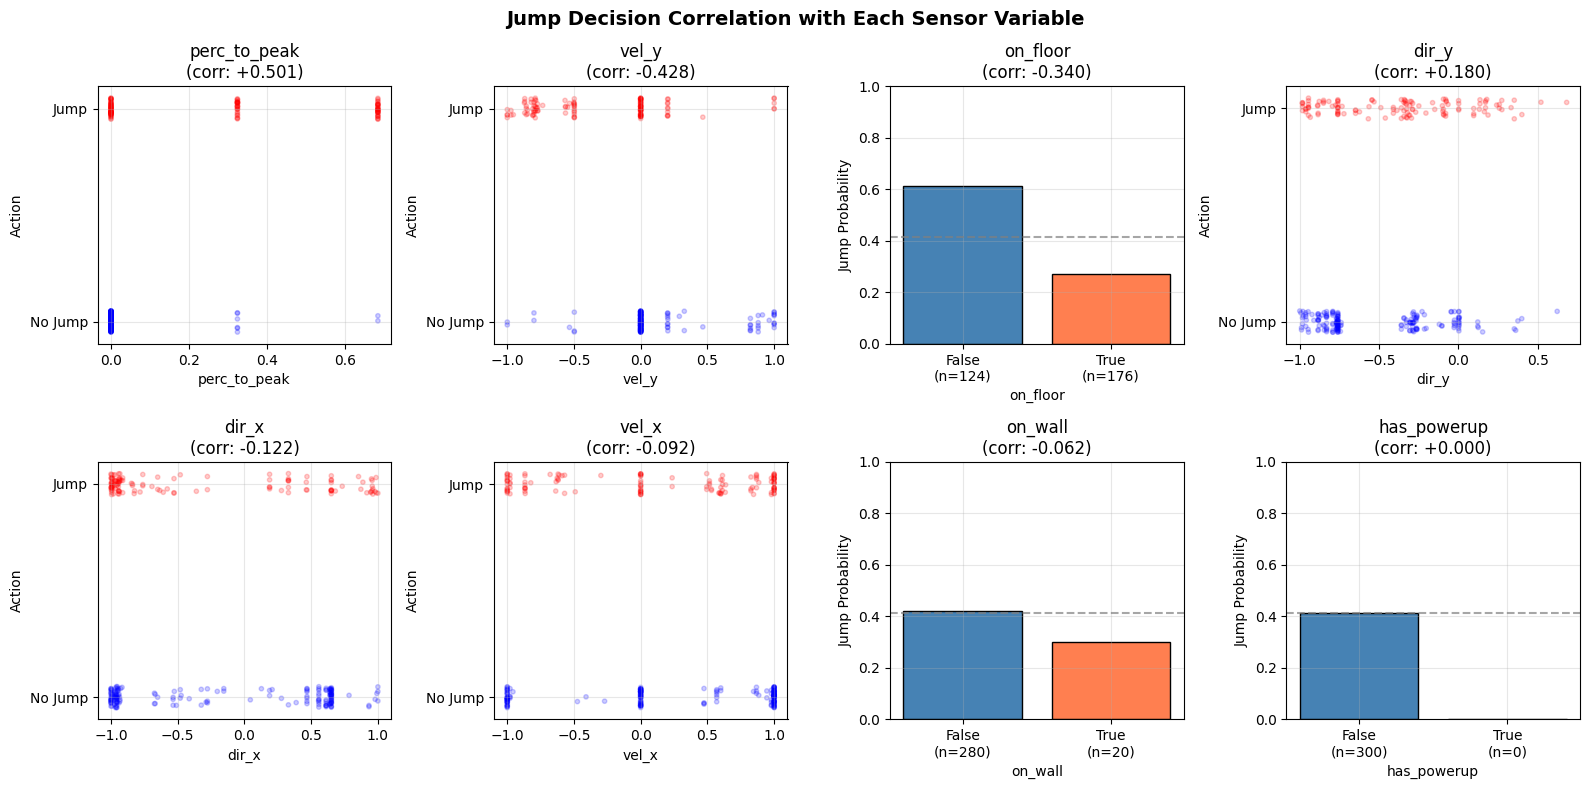


>>> Most correlated variable: 'perc_to_peak' with correlation +0.501


In [6]:
# Load gameplay data and analyze jump behavior vs ALL sensor variables
import json
import sys
sys.path.insert(0, '../src')

from utils import load_observations_by_session

# Load the recorded session
data_path = "../data/cheatsheet/session_2/recorded_session_20260415_085307.jsonl"
observations_by_session = load_observations_by_session(data_path)

# Extract all frames
all_frames = []
for session_id, frames in observations_by_session.items():
    all_frames.extend(frames)

print(f"Loaded {len(all_frames)} frames from {len(observations_by_session)} sessions")

# Sensor labels (last 8 values of state)
sensor_labels = ["dir_x", "dir_y", "vel_x", "vel_y", "on_floor", "on_wall", "perc_to_peak", "has_powerup"]

# Extract all sensor values and actions
sensor_data = {label: [] for label in sensor_labels}
actions = []

for frame in all_frames:
    state = frame['state']
    extras = state[-8:]  # Last 8 values are sensor values
    
    for i, label in enumerate(sensor_labels):
        sensor_data[label].append(extras[i])
    actions.append(frame['action'])

# Convert to numpy arrays
for label in sensor_labels:
    sensor_data[label] = np.array(sensor_data[label])
actions = np.array(actions)

print(f"Overall jump rate: {actions.mean()*100:.1f}%")

# Calculate correlation of each sensor with jump action
correlations = {}
for label in sensor_labels:
    corr = np.corrcoef(sensor_data[label], actions)[0, 1]
    correlations[label] = corr if not np.isnan(corr) else 0
    print(f"{label:15s}: correlation = {corr:+.3f}")

# Sort by absolute correlation
sorted_labels = sorted(sensor_labels, key=lambda x: abs(correlations[x]), reverse=True)

# Plot all 8 sensor variables
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, label in enumerate(sorted_labels):
    ax = axes[idx]
    values = sensor_data[label]
    corr = correlations[label]
    
    # For binary variables (on_floor, on_wall, has_powerup), show bar chart
    if label in ['on_floor', 'on_wall', 'has_powerup']:
        jump_rate_0 = actions[values == 0].mean() if (values == 0).sum() > 0 else 0
        jump_rate_1 = actions[values == 1].mean() if (values == 1).sum() > 0 else 0
        count_0 = (values == 0).sum()
        count_1 = (values == 1).sum()
        
        ax.bar([0, 1], [jump_rate_0, jump_rate_1], color=['steelblue', 'coral'], edgecolor='black')
        ax.set_xticks([0, 1])
        ax.set_xticklabels([f'False\n(n={count_0})', f'True\n(n={count_1})'])
        ax.set_ylabel('Jump Probability')
        ax.set_ylim(0, 1)
        ax.axhline(y=actions.mean(), color='gray', linestyle='--', alpha=0.7)
    else:
        # For continuous variables, scatter plot with jitter
        jitter = np.random.uniform(-0.05, 0.05, len(actions))
        colors = ['blue' if a == 0 else 'red' for a in actions]
        ax.scatter(values, actions + jitter, c=colors, alpha=0.2, s=10)
        ax.set_ylabel('Action')
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['No Jump', 'Jump'])
    
    ax.set_xlabel(label)
    ax.set_title(f'{label}\n(corr: {corr:+.3f})')
    ax.grid(True, alpha=0.3)

plt.suptitle('Jump Decision Correlation with Each Sensor Variable', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print the winner
best_label = sorted_labels[0]
print(f"\n>>> Most correlated variable: '{best_label}' with correlation {correlations[best_label]:+.3f}")

In [ ]:
# Binary classification data - fitting with SGD (interactive visualization)
np.random.seed(42)

# Generate binary classification data
n_samples = 100
hours_studied = np.random.uniform(0, 10, n_samples)

# Pass if hours > threshold (with some noise)
threshold = 5
noise = np.random.randn(n_samples) * 1.5
passed = (hours_studied + noise > threshold).astype(int)

print(f"Pass rate: {passed.mean()*100:.1f}%")

MAX_EPOCHS = 15
SEED = 42

def calculate_mse_binary(W, b):
    """Calculate Mean Squared Error for binary data"""
    y_pred = W * hours_studied + b
    return np.mean((passed - y_pred) ** 2)

# Random initial W and b within the visualization range
np.random.seed(SEED)
W_init = np.random.uniform(-0.1, 0.2)
b_init = np.random.uniform(-0.5, 0.5)

# Manual SGD training
W, b = W_init, b_init
learning_rate = 0.01

# Store history of W, b, mse at each epoch (including initial state)
sgd_history_binary = [{'W': W_init, 'b': b_init, 'mse': calculate_mse_binary(W_init, b_init)}]

for epoch in range(MAX_EPOCHS):
    # Shuffle data for SGD
    indices = np.random.permutation(n_samples)
    
    for i in indices:
        x_i = hours_studied[i]
        y_i = passed[i]
        
        # Forward pass
        y_pred = W * x_i + b
        
        # Compute gradients
        error = y_pred - y_i
        dW = 2 * error * x_i
        db = 2 * error
        
        # Update parameters
        W -= learning_rate * dW
        b -= learning_rate * db
    
    sgd_history_binary.append({'W': W, 'b': b, 'mse': calculate_mse_binary(W, b)})

print(f"Training complete! Final W = {sgd_history_binary[-1]['W']:.4f}, b = {sgd_history_binary[-1]['b']:.2f}, MSE = {sgd_history_binary[-1]['mse']:.4f}")

# Precompute MSE values for 3D scatter plot
W_range = np.linspace(-0.1, 0.2, 25)
b_range = np.linspace(-0.5, 0.5, 25)
W_pts_bin, b_pts_bin, mse_pts_bin = [], [], []

for w in W_range:
    for b in b_range:
        W_pts_bin.append(w)
        b_pts_bin.append(b)
        mse_pts_bin.append(calculate_mse_binary(w, b))

W_pts_bin = np.array(W_pts_bin)
b_pts_bin = np.array(b_pts_bin)
mse_pts_bin = np.array(mse_pts_bin)

def compute_gradient_binary(W, b):
    """Compute gradient of MSE with respect to W and b"""
    y_pred = W * hours_studied + b
    error = y_pred - passed
    dW = 2 * np.mean(error * hours_studied)
    db = 2 * np.mean(error)
    return dW, db

# Precompute jitter and colors so they stay consistent across epochs
jitter_binary = np.random.uniform(-0.03, 0.03, len(passed))
colors_binary = ['red' if p == 0 else 'green' for p in passed]

def plot_binary_sgd(epoch=0, azimuth=45, elevation=25):
    current = sgd_history_binary[epoch]
    W, b, mse = current['W'], current['b'], current['mse']
    
    fig = plt.figure(figsize=(14, 5))
    
    # Left plot: scatter data + line (2D)
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.scatter(hours_studied, passed + jitter_binary, c=colors_binary, alpha=0.6, s=60, 
                label='Data (red=Fail, green=Pass)')
    
    x_line = np.linspace(-1, 11, 100)
    y_line = W * x_line + b
    ax1.plot(x_line, y_line, 'b-', linewidth=3, label=f'y = {W:.2f}x + {b:.2f}')
    
    ax1.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
    ax1.axhline(y=1, color='gray', linestyle=':', alpha=0.5)
    ax1.set_xlim(-0.5, 10.5)
    ax1.set_ylim(-0.3, 1.3)
    ax1.set_xlabel('Hours Studied')
    ax1.set_ylabel('Pass (1) / Fail (0)')
    ax1.set_title(f'Epoch {epoch}')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Right plot: 3D scatter of MSE error surface
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.scatter(W_pts_bin, b_pts_bin, mse_pts_bin, c=mse_pts_bin, cmap='viridis', alpha=0.6, s=20)
    
    # Plot path up to current epoch
    path_W = [h['W'] for h in sgd_history_binary[:epoch+1]]
    path_b = [h['b'] for h in sgd_history_binary[:epoch+1]]
    path_mse = [h['mse'] for h in sgd_history_binary[:epoch+1]]
    
    if len(path_W) > 1:
        ax2.plot(path_W, path_b, path_mse, 'white', linewidth=2, alpha=0.8)
        ax2.scatter(path_W[:-1], path_b[:-1], path_mse[:-1], c='white', s=30, edgecolors='black', linewidths=0.5)
    
    # Compute gradient at current position
    dW, db = compute_gradient_binary(W, b)
    
    # Normalize and scale the gradient for visualization
    grad_magnitude = np.sqrt(dW**2 + db**2)
    if grad_magnitude > 0:
        scale = 0.02
        dW_norm = -dW / grad_magnitude * scale
        db_norm = -db / grad_magnitude * scale * 5
        
        W_end = W + dW_norm
        b_end = b + db_norm
        mse_end = calculate_mse_binary(W_end, b_end)
        
        ax2.plot([W, W_end], [b, b_end], [mse, mse_end], 'r-', linewidth=3, label='Gradient direction')
    
    # Mark current position with YELLOW ball
    ax2.scatter([W], [b], [mse], c='yellow', s=200, edgecolors='black', linewidths=2, zorder=10)
    
    ax2.set_xlabel('W (slope)')
    ax2.set_ylabel('b (intercept)')
    ax2.set_zlabel('MSE')
    ax2.set_title(f'Error Surface (MSE: {mse:.4f})')
    ax2.view_init(elev=elevation, azim=azimuth)
    
    plt.tight_layout()
    plt.show()

interact(
    plot_binary_sgd,
    epoch=IntSlider(min=0, max=len(sgd_history_binary)-1, step=1, value=0, description='Epoch'),
    azimuth=IntSlider(min=0, max=360, step=5, value=45, description='Rotate (°)'),
    elevation=IntSlider(min=0, max=90, step=5, value=25, description='Tilt (°)')
)

Pass rate: 44.0%
Training complete! Final W = 0.1523, b = -0.20, MSE = 0.0973


interactive(children=(IntSlider(value=0, description='Epoch', max=15), IntSlider(value=45, description='Rotate…

<function __main__.plot_binary_sgd(epoch=0, azimuth=45, elevation=25)>

In [ ]:
# Logistic Regression with SGD - using sklearn's SGDClassifier
# This uses log loss (cross-entropy) + sigmoid internally
from sklearn.linear_model import SGDClassifier

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def calculate_mse_logistic(W, b):
    """Calculate MSE with sigmoid activation"""
    z = W * hours_studied + b
    y_pred = sigmoid(z)
    return np.mean((passed - y_pred) ** 2)

# Reshape for sklearn
X_binary = hours_studied.reshape(-1, 1)

# Normalize features
scaler_binary = StandardScaler()
X_binary_scaled = scaler_binary.fit_transform(X_binary)

# Random initial weights
np.random.seed(SEED)
W_init_log = np.random.uniform(-1, 1)
b_init_log = np.random.uniform(-1, 1)

# SGDClassifier with log loss = logistic regression
model_log = SGDClassifier(
    loss='log_loss',
    learning_rate='constant',
    eta0=0.1,
    max_iter=1,
    tol=None,
    warm_start=True,
    random_state=SEED
)

# Initialize and set custom starting weights
model_log.partial_fit(X_binary_scaled, passed, classes=[0, 1])
model_log.coef_ = np.array([[W_init_log]])
model_log.intercept_ = np.array([b_init_log])

# Convert scaled weights to original scale for visualization
def get_original_weights(W_scaled, b_scaled):
    W = W_scaled / scaler_binary.scale_[0]
    b = b_scaled - W_scaled * scaler_binary.mean_[0] / scaler_binary.scale_[0]
    return W, b

W_orig, b_orig = get_original_weights(W_init_log, b_init_log)
sgd_history_log = [{'W': W_orig, 'b': b_orig, 'mse': calculate_mse_logistic(W_orig, b_orig)}]

for epoch in range(MAX_EPOCHS):
    model_log.partial_fit(X_binary_scaled, passed)
    W_scaled, b_scaled = model_log.coef_[0, 0], model_log.intercept_[0]
    W, b = get_original_weights(W_scaled, b_scaled)
    sgd_history_log.append({'W': W, 'b': b, 'mse': calculate_mse_logistic(W, b)})

print(f"Training complete! Final W = {sgd_history_log[-1]['W']:.4f}, b = {sgd_history_log[-1]['b']:.2f}, MSE = {sgd_history_log[-1]['mse']:.4f}")

# Precompute MSE surface
W_range_log = np.linspace(-0.5, 2, 25)
b_range_log = np.linspace(-8, 2, 25)
W_pts_log, b_pts_log, mse_pts_log = [], [], []

for w in W_range_log:
    for b in b_range_log:
        W_pts_log.append(w)
        b_pts_log.append(b)
        mse_pts_log.append(calculate_mse_logistic(w, b))

W_pts_log = np.array(W_pts_log)
b_pts_log = np.array(b_pts_log)
mse_pts_log = np.array(mse_pts_log)

def compute_gradient_mse_logistic(W, b):
    """Compute gradient of MSE with sigmoid"""
    z = W * hours_studied + b
    y_pred = sigmoid(z)
    error = y_pred - passed
    sigmoid_deriv = y_pred * (1 - y_pred)
    dW = 2 * np.mean(error * sigmoid_deriv * hours_studied)
    db = 2 * np.mean(error * sigmoid_deriv)
    return dW, db

def plot_logistic_sgd(epoch=0, azimuth=45, elevation=25):
    current = sgd_history_log[epoch]
    W, b, mse = current['W'], current['b'], current['mse']
    
    fig = plt.figure(figsize=(14, 5))
    
    # Left plot: scatter data + sigmoid curve
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.scatter(hours_studied, passed + jitter_binary, c=colors_binary, alpha=0.6, s=60, 
                label='Data (red=Fail, green=Pass)')
    
    x_line = np.linspace(-1, 11, 100)
    y_line = sigmoid(W * x_line + b)
    ax1.plot(x_line, y_line, 'b-', linewidth=3, label=f'σ({W:.2f}x + {b:.2f})')
    
    ax1.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
    ax1.axhline(y=1, color='gray', linestyle=':', alpha=0.5)
    ax1.axhline(y=0.5, color='orange', linestyle='--', alpha=0.7, label='Decision boundary (0.5)')
    ax1.set_xlim(-0.5, 10.5)
    ax1.set_ylim(-0.1, 1.1)
    ax1.set_xlabel('Hours Studied')
    ax1.set_ylabel('P(Pass)')
    ax1.set_title(f'Epoch {epoch} - Logistic Regression (sigmoid output)')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Right plot: 3D MSE surface
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.scatter(W_pts_log, b_pts_log, mse_pts_log, c=mse_pts_log, cmap='viridis', alpha=0.6, s=20)
    
    # Plot path up to current epoch
    path_W = [h['W'] for h in sgd_history_log[:epoch+1]]
    path_b = [h['b'] for h in sgd_history_log[:epoch+1]]
    path_mse = [h['mse'] for h in sgd_history_log[:epoch+1]]
    
    if len(path_W) > 1:
        ax2.plot(path_W, path_b, path_mse, 'white', linewidth=2, alpha=0.8)
        ax2.scatter(path_W[:-1], path_b[:-1], path_mse[:-1], c='white', s=30, edgecolors='black', linewidths=0.5)
    
    # Gradient direction
    dW, db = compute_gradient_mse_logistic(W, b)
    grad_magnitude = np.sqrt(dW**2 + db**2)
    if grad_magnitude > 0.001:
        scale = 0.2
        dW_norm = -dW / grad_magnitude * scale
        db_norm = -db / grad_magnitude * scale * 5
        
        W_end = W + dW_norm
        b_end = b + db_norm
        mse_end = calculate_mse_logistic(W_end, b_end)
        
        ax2.plot([W, W_end], [b, b_end], [mse, mse_end], 'r-', linewidth=3)
    
    ax2.scatter([W], [b], [mse], c='yellow', s=200, edgecolors='black', linewidths=2, zorder=10)
    
    ax2.set_xlabel('W (slope)')
    ax2.set_ylabel('b (intercept)')
    ax2.set_zlabel('MSE')
    ax2.set_title(f'Error Surface (MSE: {mse:.4f})')
    ax2.view_init(elev=elevation, azim=azimuth)
    
    plt.tight_layout()
    plt.show()

interact(
    plot_logistic_sgd,
    epoch=IntSlider(min=0, max=len(sgd_history_log)-1, step=1, value=0, description='Epoch'),
    azimuth=IntSlider(min=0, max=360, step=5, value=45, description='Rotate (°)'),
    elevation=IntSlider(min=0, max=90, step=5, value=25, description='Tilt (°)')
)

Training complete! Final W = 1.1415, b = -6.09, MSE = 0.0746


interactive(children=(IntSlider(value=0, description='Epoch', max=15), IntSlider(value=45, description='Rotate…

<function __main__.plot_logistic_sgd(epoch=0, azimuth=45, elevation=25)>